In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.preprocessing import StandardScaler

In [20]:
dataset = pd.read_csv(r'D:\HopeAI\Training\Week9-ML and Data Science Capstone\1. Data Collection\real_estate_dataset.csv')
dataset

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,138.338057,2,2,2,1967,1,0,16,4.296086,5.562583,488496.350722
496,497,195.914028,2,3,1,1977,0,1,45,7.406261,2.845105,657736.921717
497,498,69.433659,1,1,2,2004,0,0,18,8.629724,6.263264,405324.950201
498,499,293.598702,5,1,3,1940,1,0,41,5.318891,16.990684,773035.968028


# Data Preprocessing

In [21]:
#Check of null values in rows
dataset.isnull().sum()

ID                    0
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Year_Built            0
Has_Garden            0
Has_Pool              0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64

In [33]:
#Handle missing values

dataset.dropna()

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,138.338057,2,2,2,1967,1,0,16,4.296086,5.562583,488496.350722
496,497,195.914028,2,3,1,1977,0,1,45,7.406261,2.845105,657736.921717
497,498,69.433659,1,1,2,2004,0,0,18,8.629724,6.263264,405324.950201
498,499,293.598702,5,1,3,1940,1,0,41,5.318891,16.990684,773035.968028


In [34]:
# Fill with mean
dataset.fillna(dataset.mean())

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,138.338057,2,2,2,1967,1,0,16,4.296086,5.562583,488496.350722
496,497,195.914028,2,3,1,1977,0,1,45,7.406261,2.845105,657736.921717
497,498,69.433659,1,1,2,2004,0,0,18,8.629724,6.263264,405324.950201
498,499,293.598702,5,1,3,1940,1,0,41,5.318891,16.990684,773035.968028


In [37]:
# Fill with median
dataset['Square_Feet'].fillna(dataset['Square_Feet'].mean(), inplace=True)

# # Univariate
    

In [38]:
from Univariate import Univariate

#Seggregate Quantitative and Qualitative data
quan,qual = Univariate.Quanqual(dataset)

In [39]:
dataset[quan]

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
0,1,143.635030,1,3,3,1967,1,1,48,8.297631,5.935734,602134.816747
1,2,287.678577,1,2,1,1949,0,1,37,6.061466,10.827392,591425.135386
2,3,232.998485,1,3,2,1923,1,0,14,2.911442,6.904599,464478.696880
3,4,199.664621,5,2,2,1918,0,0,17,2.070949,8.284019,583105.655996
4,5,89.004660,4,3,3,1999,1,0,34,1.523278,14.648277,619879.142523
...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,138.338057,2,2,2,1967,1,0,16,4.296086,5.562583,488496.350722
496,497,195.914028,2,3,1,1977,0,1,45,7.406261,2.845105,657736.921717
497,498,69.433659,1,1,2,2004,0,0,18,8.629724,6.263264,405324.950201
498,499,293.598702,5,1,3,1940,1,0,41,5.318891,16.990684,773035.968028


In [40]:
#Get Unique Values	Frequency	Relative Frequency	Cummulative Frequency
Univariate.getFrequency(dataset, quan)["Square_Feet"]


,Unique Values,Frequency,Relative Frequency,Cummulative Frequency
0,79.541207,1,0.002,1
1,158.462912,1,0.002,2
2,105.898960,1,0.002,3
3,127.745580,1,0.002,4
4,73.495485,1,0.002,5
...,...,...,...,...
495,132.166136,1,0.002,496
496,95.456242,1,0.002,497
497,287.678577,1,0.002,498
498,77.799371,1,0.002,499


In [41]:
#Get all values 
Univariate.CreateDataFrame(dataset, quan)

,ID,Square_Feet,Num_Bedrooms,Num_Bathrooms,Num_Floors,Year_Built,Has_Garden,Has_Pool,Garage_Size,Location_Score,Distance_to_Center,Price
Mean,250.5,174.64,2.958,1.976,1.964,1957.6,0.536,0.492,30.174,5.16441,10.4696,582210
Median,250.5,178.291,3,2,2,1959,1,0,30,5.20652,10.8861,574724
Mode,1,51.2654,1,1,2,1920,1,0,26,0.00442781,0.0628181,276892
Q1:25%,125.75,110.32,2,1,1,1926,0,0,20,2.76065,6.06675,503080
Q2:50%,250.5,178.291,3,2,2,1959,1,0,30,5.20652,10.8861,574724
Q3:75%,375.25,239.031,4,3,3,1988,1,1,41,7.73293,15.0726,665942
99%,495.01,296.554,5,3,3,2020,1,1,49,9.9021,19.725,864332
Q4:100%,500,298.241,5,3,3,2022,1,1,49,9.99544,19.928,960678
IQR,249.5,128.711,2,2,2,62,1,1,21,4.97228,9.00584,162862
1.5Rule,374.25,193.067,3,3,3,93,1.5,1.5,31.5,7.45843,13.5088,244293


# # Bivariant
# # Variance_Inflation_Factor

In [42]:
#Variance_Inflation_Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [43]:
calc_vif(dataset[['Location_Score', 'Distance_to_Center']])

,variables,VIF
0,Location_Score,2.604653
1,Distance_to_Center,2.604653


# # Independant Sample- Unpaired T Test

In [44]:
# Diferrent Group(Has Garden) but same contion(Price)

from scipy.stats import ttest_ind

Has_Garden = dataset[dataset['Has_Garden'] == 1]['Price']
No_Garden = dataset[dataset['Has_Garden'] == 0]['Price']
ttest_ind(Has_Garden, No_Garden)


Ttest_indResult(statistic=2.4514697900485136, pvalue=0.014569918109934582)

# # ANAVO : Analysis of Variance

In [45]:
import scipy.stats as stats

g1 = dataset[dataset['Num_Floors'] == 1]['Price']
g2 = dataset[dataset['Num_Floors'] == 2]['Price']
g3 = dataset[dataset['Num_Floors'] == 3]['Price']

stats.f_oneway(g1, g2, g3)

F_onewayResult(statistic=8.907962143670218, pvalue=0.00015814211718859862)

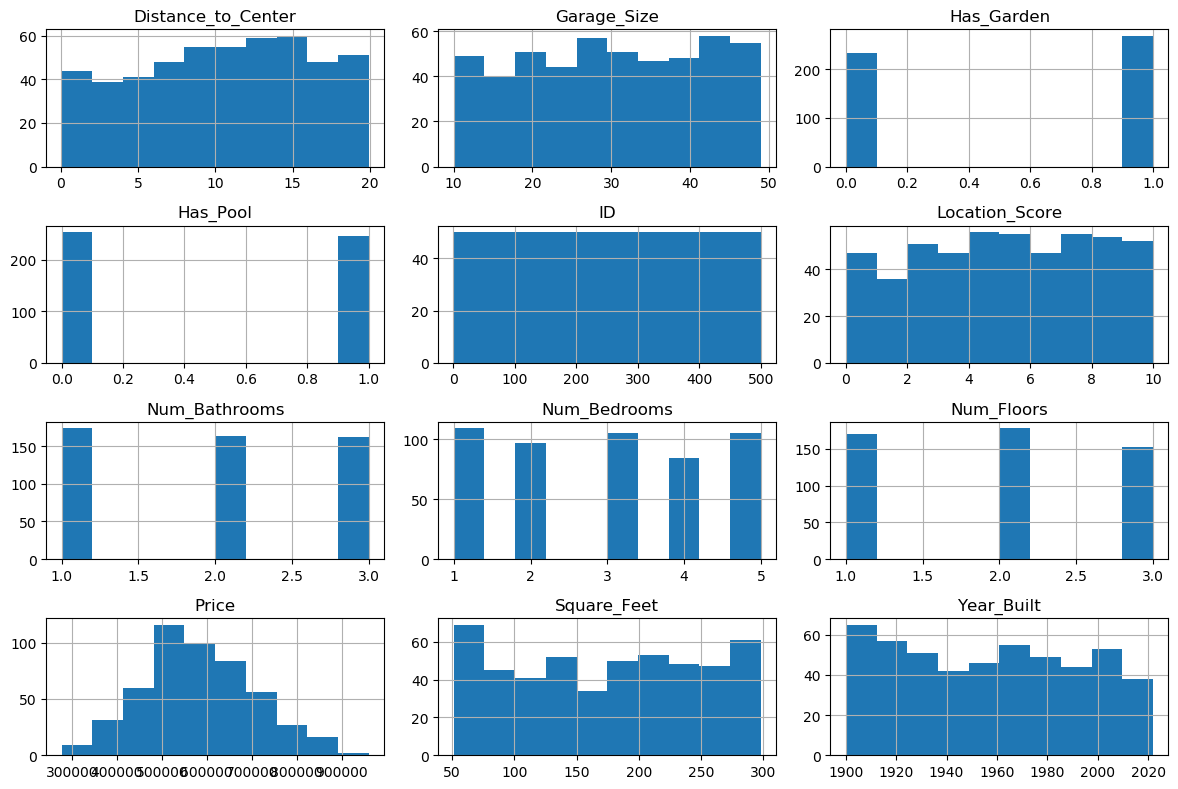

In [46]:
# Histograms Plot

dataset.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

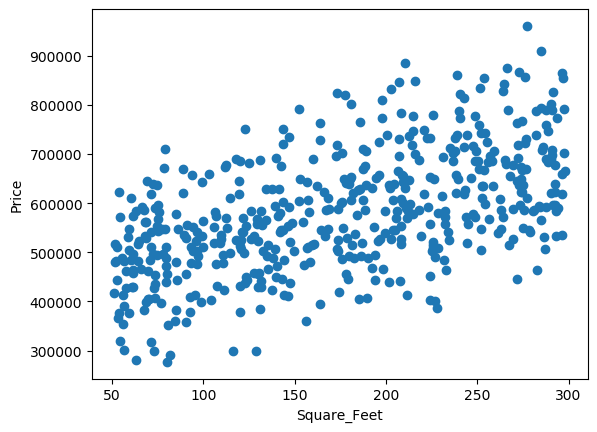

In [47]:
# Scattered Plot

import matplotlib.pyplot as plt

plt.scatter(dataset['Square_Feet'], dataset['Price'])
plt.xlabel('Square_Feet')
plt.ylabel('Price')
plt.show()